In [1]:
# Import core libraries

import pandas as pd
import numpy as np

# Import visualisation libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Import text classifiers
import re
import nltk
import string

# warnings
import warnings
warnings.filterwarnings("ignore")


Data loading

In [4]:
df = pd.read_csv(r"C:\users\adachukwu\onedrive\desktop\GitHub Repositories\Customer-insight-analysis\data\Customer insight review.csv")

In [ ]:
df.head(5)

In [6]:
# Make a working copy

df_copy = df.copy()

In [7]:
df_copy.head(5)

,Timestamp,Email Address,Do you own a wireless speaker?,How often do you use your wireless speaker?,How would you rate the sound quality of your wireless speaker?,explain the rating,How important is sound quality,How important is battery life,how important is design/Looks,"how important is connectivity options (e.g., Bluetooth, Wi-Fi)",...,Have any other lifestyle changes in the past year changed how you use wireless speakers?,How much did you spend on your wireless speaker? (US dollars),How likely are you to buy a new wireless speaker in the next 12 months?,Where do you like to buy wireless speakers?,How do you think about and evaluate the price when buying a wireless speaker?,How old are you?,What is your gender?,What's your annual household income?,"Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.",Score
0,7/15/2024 0:17:17,fedenakashima@gmail.com,Yes,Daily,Excellent,I think it is excellent because I have nothing...,1.0,3.0,4.0,5.0,...,"More media consumption (music, movies, games)",Less than $50,1.0,"Large multi-brand stores (e.g., Amazon)",I compare it to weather it is a better option ...,18-24,Female,"More than $100,000",-,NaN
1,7/15/2024 0:21:44,victor3flores@yahoo.com,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7/15/2024 0:38:00,joycipaluz@gmail.com,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7/15/2024 21:59:16,kandacelipscomb4@gmail.com,Yes,Once a week,Good,"It’s kinda staticky, but it gets the job done (:",4.0,1.0,3.0,5.0,...,"Spending more time at home, Home workouts",$50 to $100,3.0,"Large multi-brand stores (e.g., Amazon)",I tend to go cheaper,18-24,Female,"$25,000-$50,000",NaN,NaN
4,7/15/2024 21:59:47,lailaball1@icloud.com,Yes,Daily,Excellent,It’s a Bose and it’s the best,6.0,4.0,2.0,5.0,...,"More media consumption (music, movies, games)",$100 to $200,2.0,"Large multi-brand stores (e.g., Amazon)",Usage,18-24,Female,"$50,000-$75,000",Na,NaN


In [9]:
# Filter out to respondents that do not own a wireless speaker.

df_copy['Do you own a wireless speaker?'].value_counts()

Do you own a wireless speaker?
Yes    3604
No     1466
Name: count, dtype: int64

Out of 5,070 respondents, approximately 71% reported owning a wireless speaker, indicating strong market penetration for wireless audio devices among surveyed consumers.

In [10]:
df_users = df_copy[df_copy['Do you own a wireless speaker?'] == 'Yes']

In [11]:
df_users.head(2)

,Timestamp,Email Address,Do you own a wireless speaker?,How often do you use your wireless speaker?,How would you rate the sound quality of your wireless speaker?,explain the rating,How important is sound quality,How important is battery life,how important is design/Looks,"how important is connectivity options (e.g., Bluetooth, Wi-Fi)",...,Have any other lifestyle changes in the past year changed how you use wireless speakers?,How much did you spend on your wireless speaker? (US dollars),How likely are you to buy a new wireless speaker in the next 12 months?,Where do you like to buy wireless speakers?,How do you think about and evaluate the price when buying a wireless speaker?,How old are you?,What is your gender?,What's your annual household income?,"Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.",Score
0,7/15/2024 0:17:17,fedenakashima@gmail.com,Yes,Daily,Excellent,I think it is excellent because I have nothing...,1.0,3.0,4.0,5.0,...,"More media consumption (music, movies, games)",Less than $50,1.0,"Large multi-brand stores (e.g., Amazon)",I compare it to weather it is a better option ...,18-24,Female,"More than $100,000",-,NaN
3,7/15/2024 21:59:16,kandacelipscomb4@gmail.com,Yes,Once a week,Good,"It’s kinda staticky, but it gets the job done (:",4.0,1.0,3.0,5.0,...,"Spending more time at home, Home workouts",$50 to $100,3.0,"Large multi-brand stores (e.g., Amazon)",I tend to go cheaper,18-24,Female,"$25,000-$50,000",NaN,NaN


In [12]:
df_users.columns

Index(['Timestamp', 'Email Address', 'Do you own a wireless speaker?',
       'How often do you use your wireless speaker?',
       'How would you rate the sound quality of your wireless speaker?',
       'explain the rating', 'How important is sound quality',
       'How important is battery life', 'how important is design/Looks',
       'how important is connectivity options (e.g., Bluetooth, Wi-Fi)',
       'how important is durability', 'how important is price',
       'what brand do you own',
       'What made you buy your current wireless speaker? Recommendation from friends/family',
       'What made you buy your current wireless speaker? Online reviews from other customers ',
       'What made you buy your current wireless speaker? Expert reviews',
       'What made you buy your current wireless speaker? Brand reputation',
       'What made you buy your current wireless speaker? Price',
       'What made you buy your current wireless speaker? Specific features',
       'What ma

In [13]:
# Rename the columns

df_users = df_users.rename(columns={
'Do you own a wireless speaker?':'owns_speaker',
'How often do you use your wireless speaker?':'usage_frequency',
'How would you rate the sound quality of your wireless speaker?':'sound_quality_rating',
'explain the rating':'sound_quality_comment',
'How important is sound quality':'importance_sound_quality',
'How important is battery life':'importance_battery_life',
'how important is design/Looks':'importance_design',
'how important is connectivity options (e.g., Bluetooth, Wi-Fi)':'importance_connectivity',
'how important is durability':'importance_durability',
'how important is price':'importance_price',
'what brand do you own':'owned_brand',
'What made you buy your current wireless speaker? Recommendation from friends/family':'purchase_driver_recommendation',
'What made you buy your current wireless speaker? Online reviews from other customers ':'purchase_driver_online_reviews',
'What made you buy your current wireless speaker? Expert reviews':'purchase_driver_expert_reviews',
'What made you buy your current wireless speaker? Brand reputation':'purchase_driver_brand_reputation',
'What made you buy your current wireless speaker? Price':'purchase_driver_price',
'What made you buy your current wireless speaker? Specific features':'purchase_driver_features',
'What made you buy your current wireless speaker? Advertising':'purchase_driver_advertising',
'How happy are you with your wireless speaker?':'overall_satisfaction',
'What would make your wireless speaker better?':'improvement_suggestions',
'What do you mostly use your wireless speaker for? ':'primary_usage',
'Have any other lifestyle changes in the past year changed how you use wireless speakers? ':'lifestyle_changes_usage',
'How much did you spend on your wireless speaker? (US dollars)':'price_paid',
'How likely are you to buy a new wireless speaker in the next 12 months?':'purchase_intent',
'Where do you like to buy wireless speakers?':'purchase_channel',
'How do you think about and evaluate the price when buying a wireless speaker? ':'price_evaluation',
'How old are you?':'age',
'What is your gender?':'gender',
"What's your annual household income?":'income',
'Thanks a bunch for completing our survey! Your feedback is super valuable and will help us understand what consumers want. \n\nIf you have any extra comments or feedback, please share them below.':'additional_feedback'
})

In [14]:
df_users.columns

Index(['Timestamp', 'Email Address', 'owns_speaker', 'usage_frequency',
       'sound_quality_rating', 'sound_quality_comment',
       'importance_sound_quality', 'importance_battery_life',
       'importance_design', 'importance_connectivity', 'importance_durability',
       'importance_price', 'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income',
       'additional_feedback', 'Score'],
      dtype='str')

Data profiling & validation


In [20]:
df_users.shape

(3604, 33)

In [15]:
df_users.info()

<class 'pandas.DataFrame'>
Index: 3604 entries, 0 to 5069
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Timestamp                         3604 non-null   str    
 1   Email Address                     3604 non-null   str    
 2   owns_speaker                      3604 non-null   str    
 3   usage_frequency                   3604 non-null   str    
 4   sound_quality_rating              3604 non-null   str    
 5   sound_quality_comment             3586 non-null   str    
 6   importance_sound_quality          3604 non-null   float64
 7   importance_battery_life           3604 non-null   float64
 8   importance_design                 3604 non-null   float64
 9   importance_connectivity           3604 non-null   float64
 10  importance_durability             3604 non-null   float64
 11  importance_price                  3604 non-null   float64
 12  owned_brand           

In [17]:
df_users.describe().T

,count,mean,std,min,25%,50%,75%,max
importance_sound_quality,3604.0,3.427303,2.142052,1.0,1.0,3.0,6.0,6.0
importance_battery_life,3604.0,3.534129,1.413900,1.0,2.0,4.0,5.0,6.0
importance_design,3604.0,3.487791,1.823648,1.0,2.0,3.0,5.0,6.0
importance_connectivity,3604.0,3.534406,1.389938,1.0,3.0,4.0,4.0,6.0
importance_durability,3604.0,3.459212,1.483278,1.0,2.0,3.0,5.0,6.0
importance_price,3604.0,3.578524,1.845758,1.0,2.0,4.0,5.0,6.0
overall_satisfaction,3604.0,4.051332,0.934060,1.0,4.0,4.0,5.0,5.0
purchase_intent,3604.0,2.374584,1.316889,1.0,1.0,2.0,3.0,5.0


In [18]:
df_users.describe(include='object').T

,count,unique,top,freq
Timestamp,3604,3548,09/10/2024 6:37,3
Email Address,3604,3576,nuroag186@gmail.com,3
owns_speaker,3604,1,Yes,3604
usage_frequency,3604,5,Several times a week,1223
sound_quality_rating,3604,5,Good,1825
sound_quality_comment,3586,3217,Good,47
owned_brand,3602,683,JBL,970
purchase_driver_recommendation,3604,5,"3 (Important, but not a deal breaker)",971
purchase_driver_online_reviews,3604,5,4,989
purchase_driver_expert_reviews,3604,5,5 (Very Important),904


In [19]:
df_users.isnull().sum()

Timestamp                              0
Email Address                          0
owns_speaker                           0
usage_frequency                        0
sound_quality_rating                   0
sound_quality_comment                 18
importance_sound_quality               0
importance_battery_life                0
importance_design                      0
importance_connectivity                0
importance_durability                  0
importance_price                       0
owned_brand                            2
purchase_driver_recommendation         0
purchase_driver_online_reviews         0
purchase_driver_expert_reviews         0
purchase_driver_brand_reputation       0
purchase_driver_price                  0
purchase_driver_features               0
purchase_driver_advertising            0
overall_satisfaction                   0
improvement_suggestions               59
primary_usage                          0
lifestyle_changes_usage               68
price_paid      

In [21]:
duplicates = int(df_users.duplicated().sum())
duplicates

0

In [22]:
df_users.columns

Index(['Timestamp', 'Email Address', 'owns_speaker', 'usage_frequency',
       'sound_quality_rating', 'sound_quality_comment',
       'importance_sound_quality', 'importance_battery_life',
       'importance_design', 'importance_connectivity', 'importance_durability',
       'importance_price', 'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income',
       'additional_feedback', 'Score'],
      dtype='str')

In [23]:
# Drop columns not relevant to the analysis
df_users = df_users.drop(columns=[
    'Timestamp',
    'Email Address',
    'additional_feedback',
    'Score'
])

In [24]:
df_users.columns

Index(['owns_speaker', 'usage_frequency', 'sound_quality_rating',
       'sound_quality_comment', 'importance_sound_quality',
       'importance_battery_life', 'importance_design',
       'importance_connectivity', 'importance_durability', 'importance_price',
       'owned_brand', 'purchase_driver_recommendation',
       'purchase_driver_online_reviews', 'purchase_driver_expert_reviews',
       'purchase_driver_brand_reputation', 'purchase_driver_price',
       'purchase_driver_features', 'purchase_driver_advertising',
       'overall_satisfaction', 'improvement_suggestions', 'primary_usage',
       'lifestyle_changes_usage', 'price_paid', 'purchase_intent',
       'purchase_channel', 'price_evaluation', 'age', 'gender', 'income'],
      dtype='str')

Exploratory Data Analysis

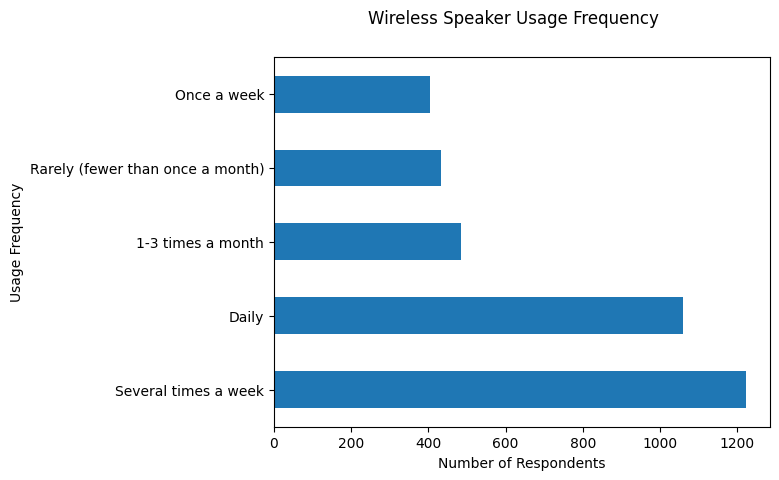

In [33]:
# graph showing usage frequency among wireless speaker owners

df_users['usage_frequency'].value_counts().plot(kind='barh')
plt.ylabel("Usage Frequency")
plt.xlabel("Number of Respondents")
plt.suptitle("Wireless Speaker Usage Frequency");

In [36]:
# what features do owners prioritise?

importance_cols = [
'importance_sound_quality',
'importance_battery_life',
'importance_design',
'importance_connectivity',
'importance_durability',
'importance_price'
]

df_users[importance_cols].mean().sort_values(ascending=False)

importance_price            3.578524
importance_connectivity     3.534406
importance_battery_life     3.534129
importance_design           3.487791
importance_durability       3.459212
importance_sound_quality    3.427303
dtype: float64

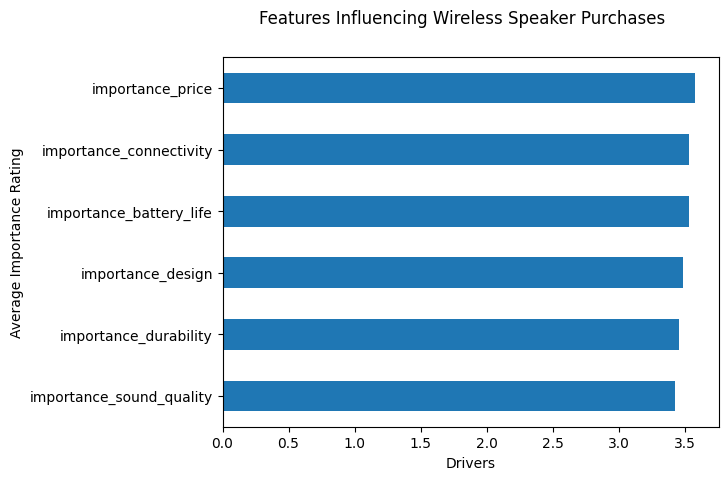

In [45]:
# visualise important factors considered before purchase

importance_drivers = df_users[importance_cols].mean().sort_values(ascending=True)

importance_drivers.plot(kind='barh')
plt.xlabel("Drivers")
plt.ylabel("Average Importance Rating")
plt.suptitle("Features Influencing Wireless Speaker Purchases")
plt.show()

In [ ]:
# Given the survey column contains string, use regex to eliminate the strings.

df_users[purchase_cols] = df_users[purchase_cols].replace(r'^(\d).*', r'\1', regex=True).astype(float)

In [39]:
# What are the purchase drivers

purchase_cols = [
'purchase_driver_recommendation',
'purchase_driver_online_reviews',
'purchase_driver_expert_reviews',
'purchase_driver_brand_reputation',
'purchase_driver_price',
'purchase_driver_features',
'purchase_driver_advertising'
]

df_users[purchase_cols].mean().sort_values(ascending=False)

purchase_driver_price               3.916759
purchase_driver_brand_reputation    3.670644
purchase_driver_features            3.411487
purchase_driver_online_reviews      3.411210
purchase_driver_expert_reviews      3.369867
purchase_driver_recommendation      2.885128
purchase_driver_advertising         2.423696
dtype: float64

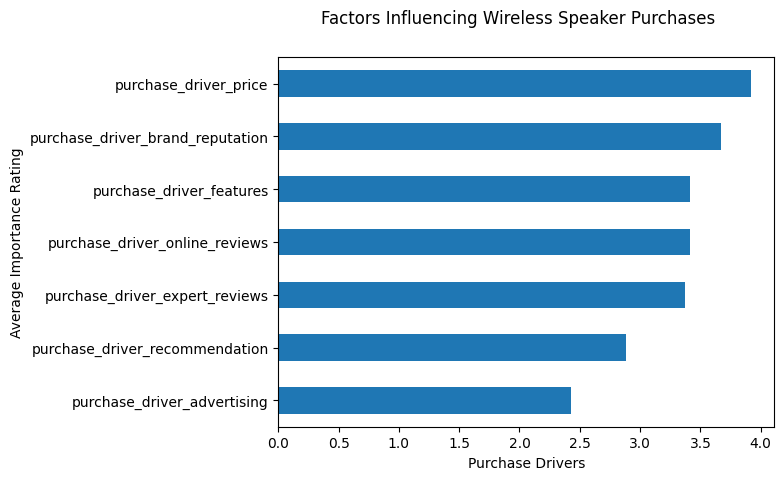

In [43]:
# Visualise the purchase driverss

purchase_drivers = df_users[purchase_cols].mean().sort_values(ascending=True)

purchase_drivers.plot(kind='barh')
plt.xlabel("Purchase Drivers")
plt.ylabel("Average Importance Rating")
plt.suptitle("Factors Influencing Wireless Speaker Purchases")
plt.show()

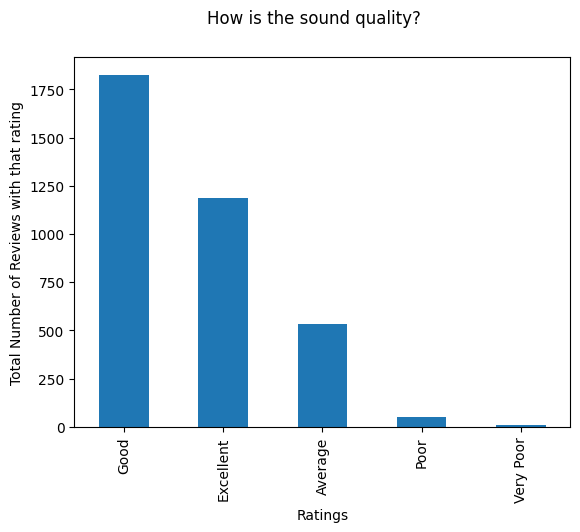

In [52]:
# How satisfied are the owners with the sound quality?

df_users['sound_quality_rating'].value_counts().plot(kind='bar')
plt.ylabel("Total Number of Reviews with that rating")
plt.xlabel("Ratings")
plt.suptitle("How is the sound quality?");

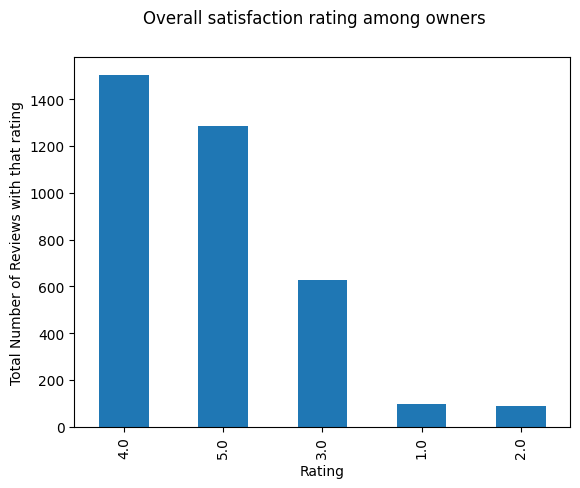

In [54]:
# How satisfied are the owners overall?

df_users["overall_satisfaction"].value_counts().plot(kind = 'bar')
plt.xlabel('Rating')
plt.ylabel('Total Number of Reviews with that rating')
plt.suptitle('Overall satisfaction rating among owners');

In [56]:
# how much do owners spend on wireless speakers?

df_users['price_paid'].value_counts()

price_paid
$50 to $100         1253
Less than $50       1133
$100 to $200         851
$200 to $300         247
- More than $300     117
More than $300         3
Name: count, dtype: int64

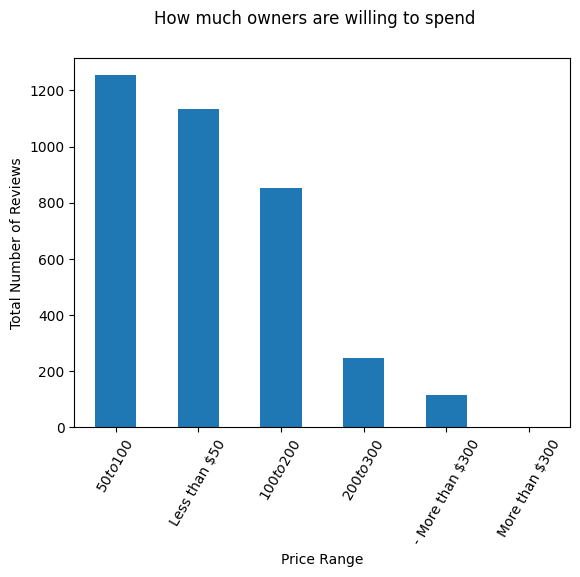

In [75]:
df_users['price_paid'].value_counts().plot(kind = 'bar')
plt.ylabel("Total Number of Reviews")
plt.xlabel("Price Range")
plt.suptitle('How much owners are willing to spend')
plt.xticks(rotation=60);


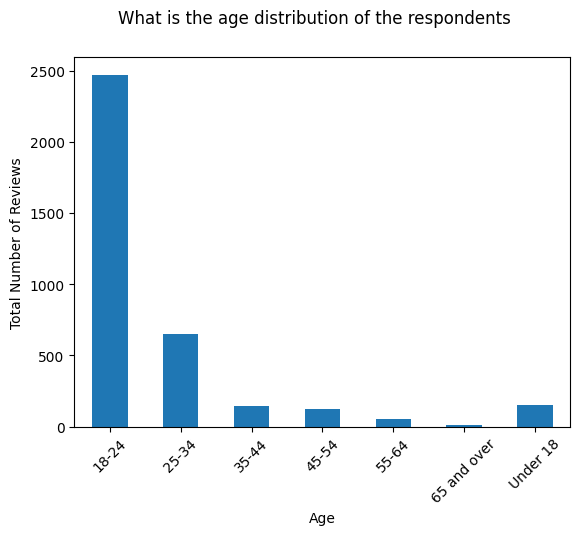

In [76]:
# Who are these owners, what age group are they?

df_users['age'].value_counts().sort_index().plot(kind = 'bar')
plt.ylabel("Total Number of Reviews")
plt.xlabel("Age")
plt.suptitle('What is the age distribution of the respondents')
plt.xticks(rotation=45);